<a href="https://colab.research.google.com/github/Pham-Duc-Anh/Plant-Disease-Detection/blob/main/plant_disease_detection_mobilenetv2_OPTIMIZED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plant Disease Detection — MobileNetV2



In [ ]:
# INSTALL & IMPORT

!pip install -q kagglehub scikit-learn

import os
import json
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


In [ ]:
# REPRODUCIBILITY

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

EXPORT_DIR = Path('/content/drive/MyDrive/leafscan_model')
LOCAL_EXPORT_DIR = Path('/content/leafscan_model')

# 1. Download Dataset từ Kaggle


In [ ]:
# DOWNLOAD DATASET

import kagglehub

DATASET = 'mohitsingh1804/plantvillage'
raw_root = Path(kagglehub.dataset_download(DATASET))
print('Dataset cached at:', raw_root)
print('Total files:', len(list(raw_root.rglob('*'))))


Using Colab cache for faster access to the 'plantvillage' dataset.
Dataset cached at: /kaggle/input/plantvillage
Total files: 54384


In [ ]:
# FIND CLASS DIRECTORY ROBUSTLY

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
candidates = []
for d in [raw_root] + [p for p in raw_root.rglob('*') if p.is_dir()]:
    subdirs = [x for x in d.iterdir() if x.is_dir()]
    if len(subdirs) < 10:
        continue
    class_like = 0
    total_imgs = 0
    for s in subdirs:
        n = sum(1 for p in s.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS)
        if n > 0:
            class_like += 1
            total_imgs += n
    if class_like >= 10:
        candidates.append((d, class_like, total_imgs))

if not candidates:
    raise RuntimeError('Không tìm thấy thư mục class. Hãy kiểm tra cấu trúc dataset Kaggle.')

candidates = sorted(candidates, key=lambda x: (x[1], x[2]), reverse=True)
dataset_dir = candidates[0][0]

print('Dataset directory:', dataset_dir)
print('Class folders:', candidates[0][1])
print('Images directly inside class folders:', candidates[0][2])
print('Example classes:', sorted([p.name for p in dataset_dir.iterdir() if p.is_dir()])[:10])


Dataset directory: /kaggle/input/plantvillage/PlantVillage/train
Class folders: 38
Images directly inside class folders: 43444
Example classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']


# 2. Tạo DataFrame file ảnh + Stratified Split


In [ ]:
# BUILD IMAGE DATAFRAME

class_names = sorted([p.name for p in dataset_dir.iterdir() if p.is_dir()])
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}

rows = []

for class_name in class_names:
    class_dir = dataset_dir / class_name

    for img_path in class_dir.rglob('*'):
        if img_path.is_file() and img_path.suffix.lower() in IMAGE_EXTS:
            rows.append({
                'path': str(img_path),
                'class_name': class_name,
                'label': class_to_idx[class_name]
            })

df = pd.DataFrame(rows)

if df.empty:
    raise RuntimeError('Không tìm thấy ảnh trong dataset_dir.')

NUM_CLASSES = len(class_names)

print('NUM_CLASSES:', NUM_CLASSES)
print('Total images:', len(df))
print('\nTop class counts:')
print(df['class_name'].value_counts().head())

# Check class dễ nhầm: Tomato / Potato
print('\nTomato/Potato class counts:')
tomato_potato_counts = df[
    df['class_name'].str.lower().str.contains('tomato|potato', regex=True)
]['class_name'].value_counts()

print(tomato_potato_counts)

print('\nTomato/Potato class indices:')
for name in class_names:
    if 'tomato' in name.lower() or 'potato' in name.lower():
        print(class_to_idx[name], '->', name)

NUM_CLASSES: 38
Total images: 43444

Top class counts:
class_name
Orange___Haunglongbing_(Citrus_greening)    4405
Tomato___Tomato_Yellow_Leaf_Curl_Virus      4286
Soybean___healthy                           4072
Peach___Bacterial_spot                      1838
Tomato___Bacterial_spot                     1702
Name: count, dtype: int64

Tomato/Potato class counts:
class_name
Tomato___Tomato_Yellow_Leaf_Curl_Virus           4286
Tomato___Bacterial_spot                          1702
Tomato___Late_blight                             1527
Tomato___Septoria_leaf_spot                      1417
Tomato___Spider_mites Two-spotted_spider_mite    1341
Tomato___healthy                                 1273
Tomato___Target_Spot                             1123
Potato___Late_blight                              800
Potato___Early_blight                             800
Tomato___Early_blight                             800
Tomato___Leaf_Mold                                761
Tomato___Tomato_mosaic_virus 

In [ ]:
# STRATIFIED TRAIN / VAL / TEST SPLIT

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df['label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df['label']
)

print('Train:', len(train_df))
print('Val:', len(val_df))
print('Test:', len(test_df))

# Kiểm tra mỗi split có đủ class.
for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(name, 'classes:', part['label'].nunique())
    missing = set(range(NUM_CLASSES)) - set(part['label'].unique())
    if missing:
        print('Missing labels:', missing)


Train: 30410
Val: 6517
Test: 6517
train classes: 38
val classes: 38
test classes: 38


In [ ]:
# TF.DATA PIPELINE

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    return img, label


def make_dataset(dataframe, training=False):
    paths = dataframe['path'].values
    labels = dataframe['label'].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

print(train_ds)


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


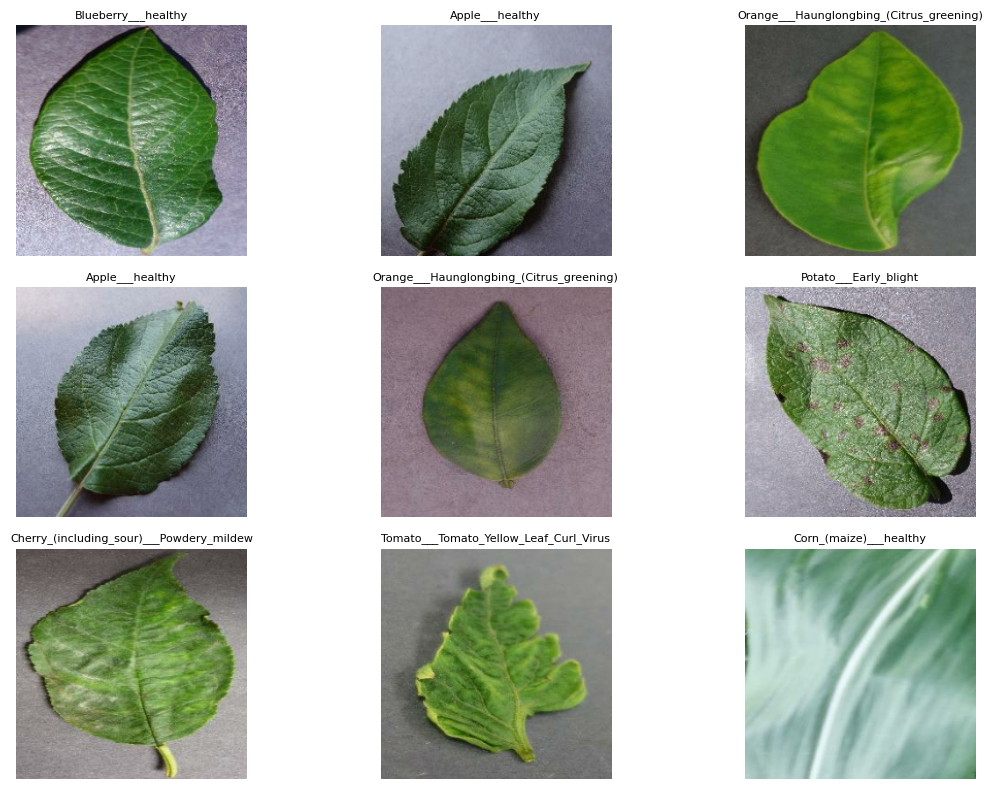

In [ ]:
# VISUALIZE DATA

plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(tf.cast(images[i], tf.uint8).numpy())
        plt.title(class_names[int(labels[i])], fontsize=8)
        plt.axis('off')
plt.tight_layout()
plt.show()


# 3. Build Model


In [ ]:
# DATA AUGMENTATION

# Augmentation vừa phải để không làm méo triệu chứng bệnh.
data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.12),
    layers.RandomContrast(0.12),
], name='data_augmentation')


In [ ]:
# BUILD MOBILENETV2 MODEL

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3), name='image_rgb_0_255')
x = data_augmentation(inputs)
x = preprocess_input(x)  # 0..255 -> [-1, 1], chuẩn MobileNetV2 official
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x) #ma trận 2D -> 1D
x = layers.Dropout(0.30)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='class_probs')(x)

model = models.Model(inputs, outputs, name='leafscan_mobilenetv2')
model.summary()

assert model.output_shape[-1] == NUM_CLASSES, 'Output layer không khớp số class.'


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "leafscan_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_rgb_0_255 (InputLayer)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probs (Dense)             │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,596,710 (9.91 MB)

 Trainable params: 338,214 (1.29 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [ ]:
# COMPILE + CALLBACKS

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

LOCAL_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
checkpoint_path = str(LOCAL_EXPORT_DIR / 'best_model.keras')

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6),
    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True)
]


# 4. Train Head

In [ ]:
# TRAIN CLASSIFIER HEAD

EPOCHS_HEAD = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks
)


Epoch 1/15
951/951 ━━━━━━━━━━━━━━━━━━━━ 135s 129ms/step - accuracy: 0.8174 - loss: 0.6272 - val_accuracy: 0.9173 - val_loss: 0.2569 - learning_rate: 0.0010
Epoch 2/15
951/951 ━━━━━━━━━━━━━━━━━━━━ 77s 81ms/step - accuracy: 0.8861 - loss: 0.3611 - val_accuracy: 0.9168 - val_loss: 0.2418 - learning_rate: 0.0010
Epoch 3/15
951/951 ━━━━━━━━━━━━━━━━━━━━ 68s 72ms/step - accuracy: 0.8920 - loss: 0.3262 - val_accuracy: 0.9340 - val_loss: 0.1990 - learning_rate: 0.0010
Epoch 4/15
951/951 ━━━━━━━━━━━━━━━━━━━━ 82s 72ms/step - accuracy: 0.8992 - loss: 0.3010 - val_accuracy: 0.9337 - val_loss: 0.1927 - learning_rate: 0.0010
Epoch 5/15
951/951 ━━━━━━━━━━━━━━━━━━━━ 67s 70ms/step - accuracy: 0.9051 - loss: 0.2950 - val_accuracy: 0.9305 - val_loss: 0.2023 - learning_rate: 0.0010
Epoch 6/15
951/951 ━━━━━━━━━━━━━━━━━━━━ 84s 72ms/step - accuracy: 0.9068 - loss: 0.2824 - val_accuracy: 0.9386 - val_loss: 0.1822 - learning_rate: 0.0010
Epoch 7/15
951/951 ━━━━━━━━━━━━━━━━━━━━ 91s 82ms/step - accuracy: 0.9086 -

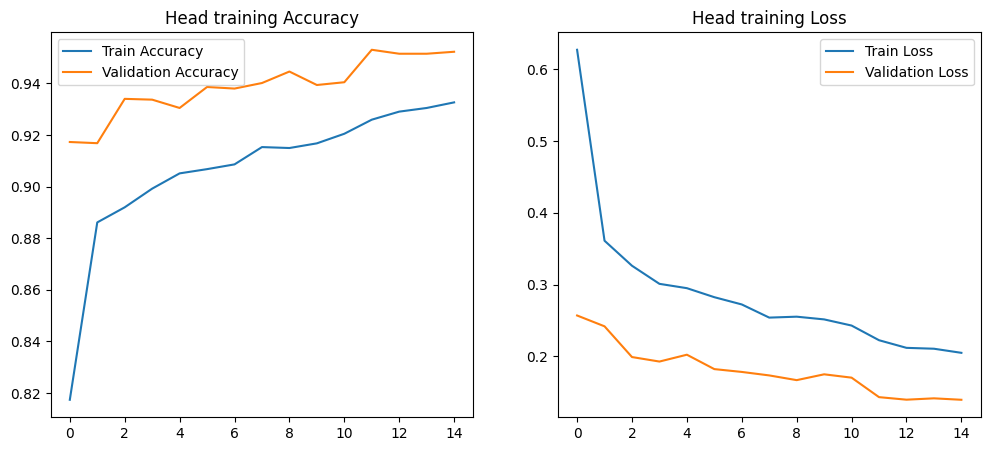

In [ ]:
# PLOT TRAINING CURVES

def plot_history(hist, title='Training'):
    acc = hist.history.get('accuracy', [])
    val_acc = hist.history.get('val_accuracy', [])
    loss = hist.history.get('loss', [])
    val_loss = hist.history.get('val_loss', [])

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title(title + ' Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(loss, label='Train Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title(title + ' Loss')
    plt.legend()
    plt.show()

plot_history(history, 'Head training')


# 5. Fine-tuning

Chỉ mở các layer cuối của MobileNetV2. Learning rate thấp để tránh phá feature ImageNet.

Epoch 1/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 87s 84ms/step - accuracy: 0.9390 - loss: 0.1824 - val_accuracy: 0.9553 - val_loss: 0.1286 - learning_rate: 1.0000e-05
Epoch 2/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 78s 82ms/step - accuracy: 0.9466 - loss: 0.1558 - val_accuracy: 0.9616 - val_loss: 0.1155 - learning_rate: 1.0000e-05
Epoch 3/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 78s 82ms/step - accuracy: 0.9524 - loss: 0.1416 - val_accuracy: 0.9653 - val_loss: 0.1001 - learning_rate: 1.0000e-05
Epoch 4/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 81s 81ms/step - accuracy: 0.9571 - loss: 0.1268 - val_accuracy: 0.9578 - val_loss: 0.1230 - learning_rate: 1.0000e-05
Epoch 5/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 78s 82ms/step - accuracy: 0.9602 - loss: 0.1187 - val_accuracy: 0.9712 - val_loss: 0.0838 - learning_rate: 1.0000e-05
Epoch 6/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 77s 81ms/step - accuracy: 0.9645 - loss: 0.1062 - val_accuracy: 0.9665 - val_loss: 0.0931 - learning_rate: 1.0000e-05
Epoch 7/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 77s 81ms/ste

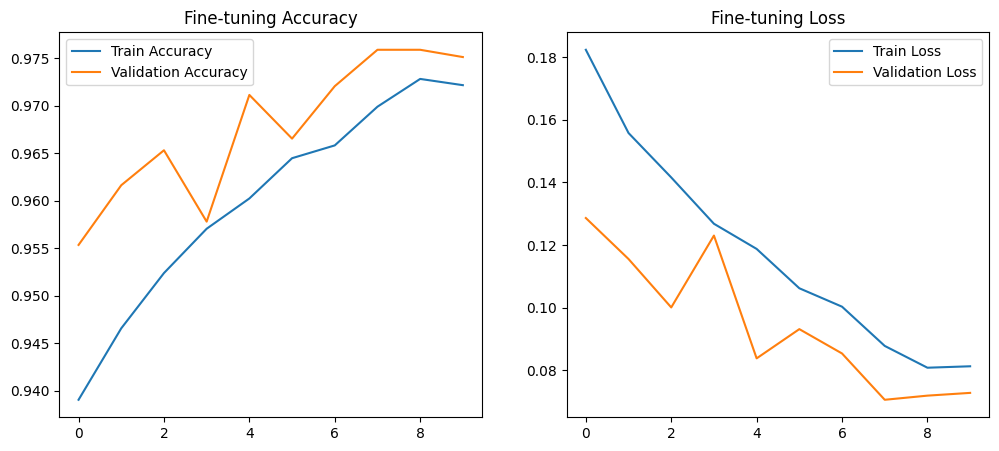

In [ ]:
# FINE TUNING

base_model.trainable = True
fine_tune_at = 120

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Giữ BatchNorm ổn định hơn khi fine-tune dataset nhỏ/không đều.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_FINE = 10
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=callbacks
)

plot_history(history_fine, 'Fine-tuning')


# 6. Evaluate + Kiểm tra riêng Tomato/Potato

In [ ]:
# EVALUATE

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print('Test Accuracy:', test_acc)
print('Test Loss:', test_loss)


204/204 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.9768 - loss: 0.0669
Test Accuracy: 0.9768298268318176
Test Loss: 0.06692129373550415


In [ ]:
# PREDICT TEST SET

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_prob.extend(np.max(probs, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)


In [ ]:
# CLASSIFICATION REPORT

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)


                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9865    0.9733    0.9799        75
                                 Apple___Black_rot     1.0000    1.0000    1.0000        74
                          Apple___Cedar_apple_rust     0.9706    1.0000    0.9851        33
                                   Apple___healthy     0.9900    1.0000    0.9950       198
                               Blueberry___healthy     0.9945    1.0000    0.9972       181
          Cherry_(including_sour)___Powdery_mildew     1.0000    0.9843    0.9921       127
                 Cherry_(including_sour)___healthy     0.9808    1.0000    0.9903       102
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.8889    0.7742    0.8276        62
                       Corn_(maize)___Common_rust_     1.0000    1.0000    1.0000       143
               Corn_(maize)___Northern_Leaf_Blight     0.8889    0.9492    0.91

Focus classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Focus test samples: 2437
                                               precision    recall  f1-score   support

                        Potato___Early_blight     0.9835    0.9917    0.9876       120
                         Potato___Late_blight     0.9573    0.9333    0.9451       120
                             Potato___healthy     1.0000    0.9444    0.9714        18
                      Tomato___Bacterial_spot     0.9540    0.9765    0.9651       255
                        Tomato___Early_blight     0.9286    0.7583    0.8349       120
                         Tomato___Late_blight     0.9565    0.9607    0

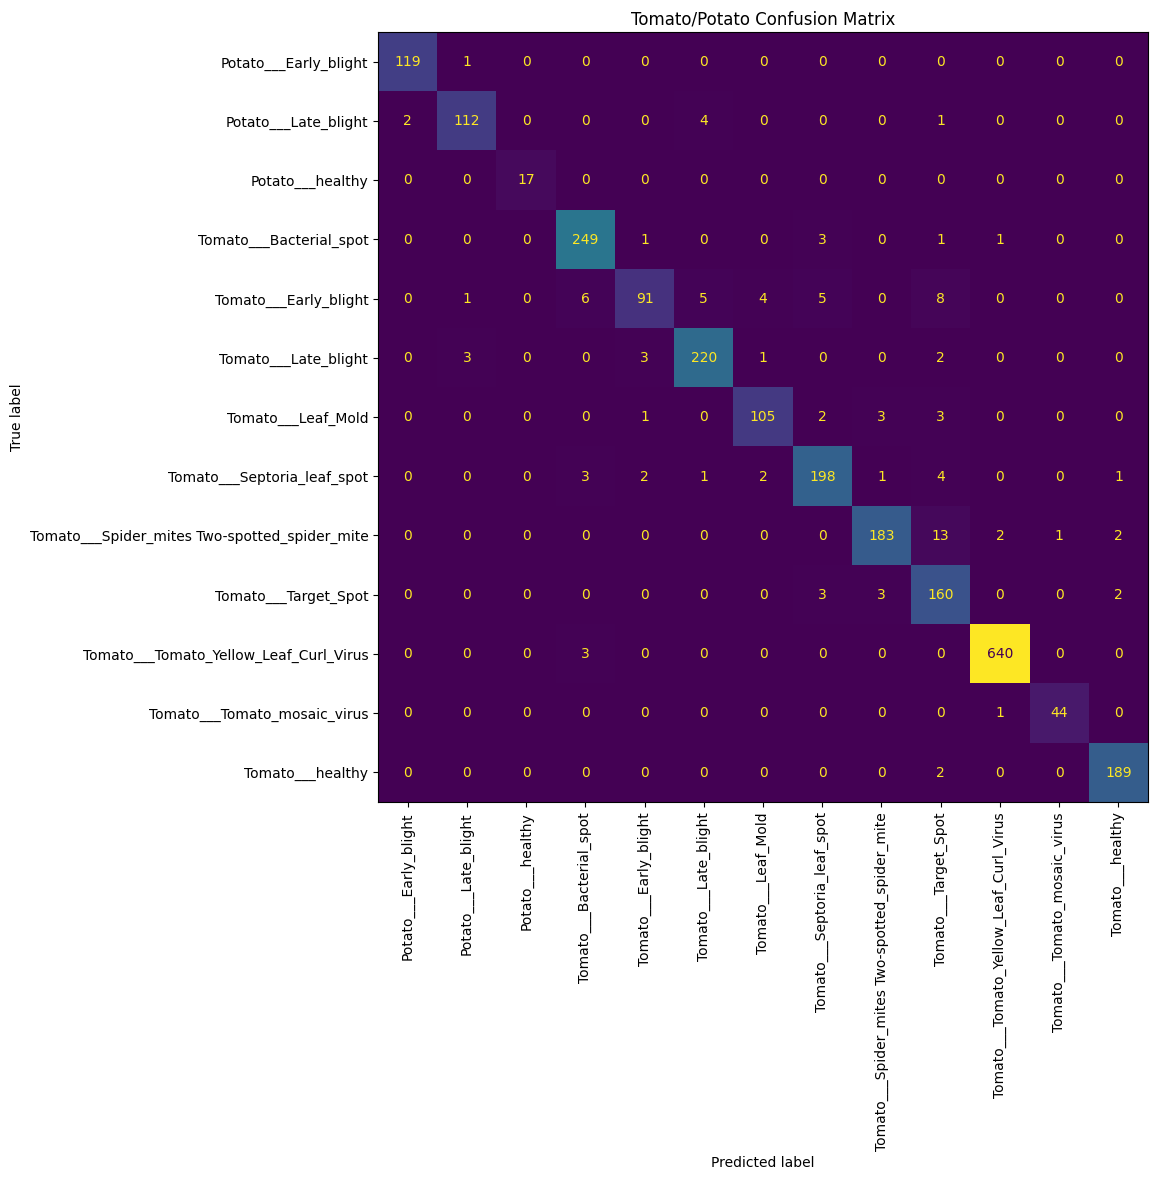

In [ ]:
# TOMATO / POTATO ONLY REPORT

focus_keywords = ['Tomato', 'Potato']
focus_indices = [i for i, name in enumerate(class_names) if any(k.lower() in name.lower() for k in focus_keywords)]
focus_names = [class_names[i] for i in focus_indices]

mask = np.isin(y_true, focus_indices)
print('Focus classes:', focus_names)
print('Focus test samples:', int(mask.sum()))

if mask.sum() > 0:
    print(classification_report(
        y_true[mask],
        y_pred[mask],
        labels=focus_indices,
        target_names=focus_names,
        digits=4,
        zero_division=0
    ))

    cm_focus = confusion_matrix(y_true[mask], y_pred[mask], labels=focus_indices)
    fig, ax = plt.subplots(figsize=(10,10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_focus, display_labels=focus_names)
    disp.plot(ax=ax, xticks_rotation=90, values_format='d', colorbar=False)
    plt.title('Tomato/Potato Confusion Matrix')
    plt.show()


# 7. Save Model + class_indices.json



In [ ]:
# MOUNT GOOGLE DRIVE

from google.colab import drive
drive.mount('/content/drive')

EXPORT_DIR.mkdir(parents=True, exist_ok=True)
print('Export dir:', EXPORT_DIR)


Mounted at /content/drive
Export dir: /content/drive/MyDrive/leafscan_model


In [ ]:
# SAVE MODEL + CLASS ORDER FILES

import tensorflow as tf
model_path_keras = EXPORT_DIR / 'plant_disease_model2.keras'
class_indices_path = EXPORT_DIR / 'class_indices.json'
classes_txt_path = EXPORT_DIR / 'classes.txt'
config_path = EXPORT_DIR / 'model_config.json'
model.save(model_path_keras)
with open(class_indices_path, 'w', encoding='utf-8') as f:
    json.dump(class_to_idx, f, ensure_ascii=False, indent=2)

with open(classes_txt_path, 'w', encoding='utf-8') as f:
    for name in class_names:
        f.write(name + '\n')

config = {
    'model_name': 'MobileNetV2 PlantVillage classifier',
    'img_size': list(IMG_SIZE),
    'num_classes': NUM_CLASSES,
    'preprocessing': 'mobilenet_v2.preprocess_input_inside_model',
    'input_range_expected_by_saved_model': 'RGB float32 0..255, resize 224x224',
    'dataset': DATASET,
    'class_source': 'class_indices.json',
    'note': 'Do not divide image by 255 in backend if using this saved model.',
    'saved_formats': ['keras']
}

with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print('Saved:')
print(model_path_keras)
print(class_indices_path)
print(classes_txt_path)
print(config_path)

try:
    loaded_keras = tf.keras.models.load_model(model_path_keras, compile=False)
    print('Loaded .keras output shape:', loaded_keras.output_shape)
    assert loaded_keras.output_shape[-1] == len(class_names)
except Exception as e:
    print('⚠️ Cannot load .keras:', e)

Saved:
/content/drive/MyDrive/leafscan_model/plant_disease_model2.keras
/content/drive/MyDrive/leafscan_model/class_indices.json
/content/drive/MyDrive/leafscan_model/classes.txt
/content/drive/MyDrive/leafscan_model/model_config.json
Loaded .keras output shape: (None, 38)


# 8. Predict ảnh từ URL hoặc upload

Hàm này dùng cùng preprocessing với model đã train. Vì preprocess nằm trong model, function chỉ resize ảnh về 224x224 và truyền float32 0..255.

In [ ]:
# PREDICT FUNCTION

import requests
from io import BytesIO
from google.colab import files


def normalize_display_name(name: str) -> str:
    return (
        name
        .replace('___', ' - ')
        .replace('__', ' - ')
        .replace('_', ' ')
        .title()
    )


def predict_pil(img: Image.Image, top_k=3):

    img = img.convert('RGB').resize(IMG_SIZE)

    arr = tf.keras.preprocessing.image.img_to_array(img).astype(np.float32)

    batch = np.expand_dims(arr, axis=0)

    probs = model.predict(batch, verbose=0)[0]

    top_idx = np.argsort(probs)[-top_k:][::-1]

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')

    title = '\n'.join([
        f'{normalize_display_name(class_names[i])}: {probs[i]*100:.2f}%'
        for i in top_idx
    ])

    plt.title(title, fontsize=10)

    plt.show()

    return [
        (class_names[i], float(probs[i]))
        for i in top_idx
    ]


def predict_image(img_path=None, url=None, top_k=3):

    if url:
        response = requests.get(url, timeout=15)
        response.raise_for_status()

        img = Image.open(BytesIO(response.content))

    elif img_path:
        img = Image.open(img_path)

    else:
        raise ValueError('Cần truyền img_path hoặc url')

    return predict_pil(img, top_k=top_k)

In [ ]:
# UPLOAD IMAGE FROM COMPUTER
uploaded = files.upload()
for file_name in uploaded.keys():
    print('Predict:', file_name)
    print(predict_image(img_path=file_name, top_k=3))
